<a href="https://colab.research.google.com/github/ParkHangah/AIFFEL_quest_eng/blob/master/Main_Quest/Quest02/LLM_MQ_gpt_vr02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# [Main Quest] **GPT만들기**

### QUEST GUIDE

#### 1. Transformer와 비교해 변경이 필요한 부분을 서술하였다.
- 제출 노트북 파일 첫부분에 텍스트 블럭으로 서술합니다. 아키텍쳐 상 변경사항을 블럭단위로 서술합니다.
- 코드블럭에 변경사항을 주석으로 표시합니다.

1. 모델 구조 변경에 따라 Encoder Layer, Encoder 삭제
2. Decoder를 Transform Block으로 단일화 하되 수식을 논문 3페이지 수식2번을 반영

#### 2. 모델의 입력 형태에 맞게 전처리를 수행하였다.
- Decoder 기반의 생성모델임을감안하여 챗봇 데이터를 변형합니다.
- 이번 과제는 pretrain을 위한 데이터셋과 학습만 고려합니다.

1. 데이터 입력 형태의 근본적 변화 (Traversal-style)
기존 코드는 질문(Q)과 답변(A)을 별도의 코퍼스로 관리하여 인코더와 디코더에 각각 입력했습니다. 하지만 GPT-1 방식에서는 이를 하나의 연속된 시퀀스로 합쳐야 합니다.  
- 기존 방식:  
Encoder Input: [BOS] + 질문 + [EOS]  
Decoder Input: [BOS] + 답변 + [EOS]
- 수정 방식 (GPT-1):  
단일 시퀀스: [Start] + 질문 + [Delimiter] + 답변 + [Extract]  
여기서 [Delimiter]는 질문과 답변을 구분하는 특수 토큰(예: $)입니다.


2. 특수 토큰(Special Tokens) 정의 및 추가
기존 SentencePiece 설정에 GPT-1 논문에서 요구하는 특수 토큰들을 추가로 반영해야 합니다.
추가 필요 토큰:
[Start]: 문장의 시작
[Delim]: 질문과 답변의 경계 ($)
[Extract]: 시퀀스의 끝 및 예측의 종결
코드 수정 방향: SentencePieceTrainer 학습 시 user_defined_symbols에 해당 토큰들을 명시적으로 추가하거나, 인코딩 시 수동으로 아이디를 부여해야 합니다.

3. encode_sentence 및 코퍼스 생성 로직 수정
두 개의 리스트(src_corpus, tgt_corpus)를 만드는 대신, 하나의 통합된 full_corpus를 생성하도록 변경합니다.

#### 3. 모델의 입력 블럭을 GPT 논문에 기반하여 수정하였다.
- 모델의 input이 정상적으로 구성되었는지확인합니다.
- 데이터에 위치 정보를 추가하는 과정을 구현합니다.

#### 4. GPT 모델을 정상적으로 구성하였다.(print(model), 훈련 진행과정 프린트 혹은 첨부)
- 노드의 transformer 코드를 수정하여 GPT1 모델을 구성합니다.

#### 5. 입력에 따른 출력이 생성되었다.
- 출력 결과물의 수준에 상관없이 모델이 정상적으로 동작하는지 확인합니다.

# A. QUEST 수행

### 0.환경구성

#### 0-1. 라이브러리 설치 & 임포트

In [1]:
# =========================================
# 0-1.1) 라이브러리 파이프라인 설치
# =========================================
!pip install kiwipiepy sentencepiece nltk transformers

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 MB 38.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.9/5.9 MB 146.8 MB/s eta 0:00:00
  Created wheel for kiwipiepy_model: filename=kiwipiepy_model-0.22.1-py3-none-any.whl size=79578111 sha256=7866717bdcc57dae952a8dea007b9b0424fd80f842bf2eee6be8a3c1f49b2ad0
  Stored in directory: /root/.cache/pip/wheels/c0/5a/4b/a1abeb73f3d31c5d010d4163bc08686d5539766084ecba0e1a
Successfully built kiwipiepy_model


In [2]:
# =========================================
# 0-1.2) 라이브러리 임포트
# =========================================

import os
import torch
import warnings   # 경고제어 0-3.한글설정
import platform   # 운영체제 정보 확인 라이브러리 0-3.한글설정
import matplotlib as mpl  # 시각화 라이브러리
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

import re
import math
import random
from collections import Counter

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from kiwipiepy import Kiwi            # 형태소 분석기 (mecab 대체)
import sentencepiece as spm
from tqdm import tqdm
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

from transformers import get_cosine_schedule_with_warmup

import seaborn as sns


#### 0-2. 코랩 사용자를 위한 드라이브 연결

##### (1) 경로 설정을 사용사 환경에 맞게 해주세요

In [3]:
# 드라이브 경로 설정  by 박항아
drive_path = '#Study/Aiffel/Work' # 평상시 작업하는 드라이브 폴더 경로를 입력해 주세요.
project_name = 'GPT'       # 이번 프로젝트세 사용하는 폴더명을 입력해주세요.

##### (2) 드라이브 연결

In [ ]:
from google.colab import drive
from IPython.display import clear_output
import ipywidgets as widgets
import os

def inf(msg, style, wdth):
    inf = widgets.Button(description=msg, disabled=True, button_style=style, layout=widgets.Layout(min_width=wdth))
    display(inf)

# 1. 구글 드라이브 마운트
print("Connecting...")
drive.mount('/content/gdrive')

# 2. 경로 설정 및 폴더 생성
base_path = os.path.join('/content/gdrive/MyDrive',drive_path)
project_path = os.path.join(base_path, project_name)

# Create the project directory if it doesn't exist
os.makedirs(project_path, exist_ok=True)

print(f"base_path: {base_path}")
# 3. 폴더 생성
print(f"Selected Google Drive root path: {base_path}")
inf('\u2714 Done','success', '50px')

#### 0-3. 한글설정

In [5]:
# 1. 폰트 경로 설정(각자 맞게 변환)
font_path = os.path.join('/content/gdrive/MyDrive', '_font/ttf/NanumBarunGothic.ttf')

In [6]:
# 특정 경고 메시지 무시 설정
# Seaborn이나 IPython에서 하단 블록 문자(Glyph 9601, ' ')를 출력할 때
# 폰트 미지원으로 발생하는 경고를 숨깁니다.
warnings.filterwarnings(
    "ignore",
    message="Glyph 9601",
    module="seaborn.utils"
)
warnings.filterwarnings(
    "ignore",
    message="Glyph 9601",
    module="IPython.core.pylabtools"
)

In [7]:
# 2. 운영체제별 환경 준비
system = platform.system()

if system == "Linux":
    # 리눅스(Colab 등) 환경에서는 시스템에 폰트 설치가 필요할 수 있음
    !apt-get install -y fonts-nanum > /dev/null

# 3. 폰트 등록 및 설정 (핵심 부분)
if os.path.exists(font_path):
    # 폰트 파일을 Matplotlib의 폰트 매니저에 직접 등록
    fm.fontManager.addfont(font_path)

    # 등록된 폰트 파일에서 실제 '폰트 이름'을 가져옴
    font_prop = fm.FontProperties(fname=font_path)
    font_name = font_prop.get_name()

    # 전역 폰트 설정 적용
    mpl.rcParams['font.family'] = font_name
    print(f"성공: {system} 환경에서 '{font_name}' 폰트가 적용되었습니다.")
else:
    print(f"경고: 폰트 파일을 찾을 수 없습니다. 경로를 확인하세요: {font_path}")
    # 파일이 없을 경우 OS 기본 폰트라도 사용하도록 백업 설정
    if system == "Windows":
        mpl.rcParams["font.family"] = "Malgun Gothic"
    elif system == "Darwin":
        mpl.rcParams["font.family"] = "AppleGothic"

# 4. 공통 마이너스 기호 및 해상도 설정
mpl.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지
%config InlineBackend.figure_format = 'retina' # 그래프 선명도 향상

성공: Linux 환경에서 'NanumBarunGothic' 폰트가 적용되었습니다.


#### 0-4. Device 설정 및 재현성 고정

In [8]:
# PyTorch 연산 장치(Device) 설정
# GPU(NVIDIA CUDA) 사용 가능 여부를 확인하여 장치를 할당합니다.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [9]:
# 재현성 고정
# 1. 난수 생성을 위한 시드(Seed) 번호 설정
# 어떤 숫자를 써도 상관없지만, 관습적으로 42를 가장 많이 사용합니다.
SEED = 42

random.seed(SEED)         # 2. Python 기본 random 모듈의 시드 고정
np.random.seed(SEED)      # 3. NumPy 라이브러리의 시드 고정 (행렬 연산 등)
torch.manual_seed(SEED)   # 4. PyTorch의 CPU 연산 시드 고정
if device.type == "cuda": # 5. GPU 연산을 사용하는 경우, 모든 GPU 장치에 대해 시드 고정
    torch.cuda.manual_seed_all(SEED)

# 연산 속도는 조금 느려질 수 있지만, 결과는 매번 동일하게 나옵니다.
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

### 1.데이터 준비

In [10]:
# 1-1. 경로 및 파일 리스트 설정
DATA_PATH = os.path.join(project_path, "data")
# 데이터가 여러개인 경우 추가할 수 있게 변경
csv_files = [
    'TS_01. KAKAO(1).csv', 'ChatbotData.csv'
]

In [11]:
# =========================================
# 1. 데이터 로드 (Chatbot_data.csv)
#    - songys/Chatbot_data 사용
# =========================================

dfs = []

for file_name in csv_files:
    file_full_path = os.path.join(DATA_PATH, file_name)

    if os.path.exists(file_full_path):
        # 파일 로드 및 필요한 컬럼(Q, A)만 추출 [2]
        temp_df = pd.read_csv(file_full_path)
        if 'Q' in temp_df.columns and 'A' in temp_df.columns:
            dfs.append(temp_df[['Q', 'A']])
            print(f"로드 완료: {file_name} (데이터: {len(temp_df)}개)")
        else:
            print(f"경고: {file_name}에 'Q' 또는 'A' 컬럼이 없습니다.")
    else:
        print(f"파일 없음: {file_full_path} 준비가 필요합니다.")

# 모든 데이터프레임을 하나로 병합
if dfs:
    df = pd.concat(dfs, axis=0, ignore_index=True).dropna()
    print(f"\n총 병합 데이터 개수: {len(df)}")
else:
    raise FileNotFoundError("병합할 데이터가 없습니다.")

로드 완료: TS_01. KAKAO(1).csv (데이터: 381981개)
로드 완료: ChatbotData.csv (데이터: 11823개)

총 병합 데이터 개수: 393804


In [12]:
# -----------------------------------------
# 1-1. 한글 정규화 & 기본 전처리 함수
# -----------------------------------------
def clean_korean_text(text: str) -> str:
    text = str(text).strip()
    # 자모 분리/이상한 문자 제거 등 간단 처리
    text = re.sub(r"[^ㄱ-ㅎ가-힣0-9a-zA-Z\?\!\.\,\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["Q_clean"] = df["Q"].apply(clean_korean_text)
df["A_clean"] = df["A"].apply(clean_korean_text)

# 너무 짧거나 긴 문장 제거
df = df[(df["Q_clean"].str.len() >= 2) & (df["Q_clean"].str.len() <= 50)]
df = df[(df["A_clean"].str.len() >= 2) & (df["A_clean"].str.len() <= 50)]

print("1차 정제 후 개수:", len(df))

1차 정제 후 개수: 384748


In [13]:
# -----------------------------------------
# 1-2. GPT 스타일의 단일 시퀀스 생성 (수정 부분)
# -----------------------------------------
# GPT1은 구조화된 입력을 단일 시퀀스로 변환하는 순회 방식을 사용함 [1]
# 형식: [Start] + 질문 + [Delim] + 답변 + [Extract]

# 논문 3.3 섹션에 따라 구분자 토큰($)을 활용함 [2]
df["Combined_text"] = df.apply(lambda x: x["Q_clean"] + " $ " + x["A_clean"], axis=1)

print("결합된 데이터 예시:", df["Combined_text"].iloc)
# Combined_text 컬럼의 상위 5개 행 출력
print(df["Combined_text"].head(5))

결합된 데이터 예시: <pandas.core.indexing._iLocIndexer object at 0x7e5dfcf2b840>
0            고양이 알러지는 없나? $ 있는 사람이 꽤 있더라고
1    있는 사람이 꽤 있더라고 $ 저 살짝 있어요 키키 심한 건 아니고
2            저 살짝 있어요 키키 심한 건 아니고 $ 아 진짜?
3                     아 진짜? $ 고양이는 못 키우겠노
4                    고양이는 못 키우겠노 $ 키워 봤음?
Name: Combined_text, dtype: object


### 2. 데이터 정제

형태소 분석 및 토큰 수준 정제

In [14]:
# =========================================
# 2. 형태소 분석 + 토큰 수준 정제 (Kiwi)
#    - mecab 대신 Kiwi 사용
# =========================================
kiwi = Kiwi()
# ------------------------------------------------------
# 토큰 정제 함수 유지 및 강화
# ------------------------------------------------------
def kiwi_tokenize(text: str):
    """
    텍스트를 형태소 단위로 분리하고 필터링합니다. [3], [4] 참고.
    """
    # 간단히 명사/동사/형용사 위주로 사용 (원하면 품사 필터링 조정)
    tokens = []
    for tok, pos, _, _ in kiwi.analyze(text, top_n=1)[0][0]:
        # 의미를 가지는 체언(NN), 용언(VV, VA), 부사(MAG), 감탄사(IC) 위주로 추출
        if pos.startswith("NN") or pos.startswith("VV") or pos.startswith("VA") or pos.startswith("MAG") or pos.startswith("IC"):
            tokens.append(tok)
        else:
            # 조사나 어미 등도 학습을 위해 포함 (GPT는 문맥 파악이 중요하므로 전체 포함 권장)
            tokens.append(tok)
            pass
    # 토큰이 너무 적으면 원문 그대로 fallback
    if len(tokens) < 2:
        return text.split()
    return tokens

def join_tokens(tokens):
    return " ".join(tokens)

df["C_tok"] = df["Combined_text"].apply(kiwi_tokenize)

# 토큰 리스트를 다시 공백 기준 문장으로 변환 (SentencePiece 학습용)
df["C_proc"] = df["C_tok"].apply(join_tokens)

# Combined_text 컬럼의 상위 5개 행 출력
print(df["C_proc"].head(5))

0                고양이 알러지 는 없 나 ? $ 있 는 사람 이 꽤 있 더라고
1    있 는 사람 이 꽤 있 더라고 $ 저 살짝 있 어요 키 키 심하 ᆫ 거 ᆫ 아니 고
2              저 살짝 있 어요 키 키 심하 ᆫ 거 ᆫ 아니 고 $ 아 진짜 ?
3                           아 진짜 ? $ 고양이 는 못 키우 겠 노
4                     고양이 는 못 키우 겠 노 $ 키우 어 보 었 음 ?
Name: C_proc, dtype: object


### 3. 데이터 증강 - 문장 수가 충분하므로 증강X

#### 3-1. 기존코드

In [20]:
# =========================================
# 3. 데이터 증강 (augmentation)
# 토큰 무작위 삭제 및 위치 변경으로 증강하기
# 기존 질문답변 교체는 삭제why? 쌍이 아닌 일렬로 변경되었으므로
# =========================================

def random_drop_tokens(tokens, drop_prob=0.05):
    """일부 토큰을 무작위로 삭제 (문맥 파악 강인함 증대)"""
    if len(tokens) <= 3: return tokens
    new_tokens = []
    for t in tokens:
        if random.random() < drop_prob:
            continue
        new_tokens.append(t)
    return new_tokens if len(new_tokens) >= 2 else tokens

def random_swap_tokens(tokens, n=1):
    """토큰의 위치를 무작위로 n번 바꿈 (어순 변화 대비)"""
    # 문장길이가 대체적으로 짧으므로 확률기반이 아니라 1회 이상 수치로 실
    if len(tokens) < 2: return tokens
    new_tokens = tokens[:]
    for _ in range(n):
        idx1, idx2 = random.sample(range(len(new_tokens)), 2)
        new_tokens[idx1], new_tokens[idx2] = new_tokens[idx2], new_tokens[idx1]
    return new_tokens

#### 3-2. 추가 증강방법 (1) 조사 삭제

In [21]:
def josa_deletion_kiwi(text):
    """
    Kiwi를 활용한 조사 삭제 (한국어 구어체 데이터 생성)
    원문을 받아서 조사를 제외한 토큰만 다시 합칩니다.
    """
    results = kiwi.analyze(text)[0][0]
    # JKS(주격), JKO(목적격) 등 조사를 제외하고 추출
    tokens = [t.form for t in results if not t.tag.startswith('J')]
    return tokens

#### 3-2. 추가 증강방법 (2) FastText 임베딩 모델을 황용한 유의어 **변경**
(용량이 너무 커서 시간관계상 사용X)

In [ ]:
# ! pip install gensim

In [ ]:
# from gensim.models.fasttext import load_facebook_model
# from gensim.models import KeyedVectors
# # fasttext_model = load_facebook_model(os.path.join(DATA_PATH, "cc.ko.300.bin"))
# fasttext_model = KeyedVectors.load_word2vec_format(os.path.join(DATA_PATH, "cc.ko.300.vec"))

# def get_synonym(word, model, top_n=1):
#     """FastText를 이용해 유사어 하나를 반환"""
#     try:
#         # 가장 유사한 단어 n개를 가져와서 랜덤하게 하나 선택 (원본 중복 방지)
#         results = model.wv.most_similar(word, topn=top_n)
#         return results[0][0] # 가장 점수 높은 단어 반환
#     except:
#         return word # 모델에 단어가 없으면 원본 반환

# def kiwi__augment(text, model, p=0.2):
#     """
#     Kiwi로 형태소를 분석하고, 명사/형용사만 FastText 유의어로 교체
#     """
#     if not text: return ""

#     # 1. Kiwi 형태소 분석
#     analysis = kiwi.analyze(text)[0][0]

#     new_tokens = []
#     for token in analysis:
#         # 교체 대상: 일반명사(NNG), 고유명사(NNP), 형용사(VA), 동사(VV)
#         if token.tag in ['NNG', 'NNP', 'VA', 'VV'] and random.random() < p:
#             # 2. FastText 유의어 교체 시도
#             synonym = get_synonym(token.form, model)
#             new_tokens.append(synonym)
#         else:
#             # 조사, 어미 및 확률에 걸리지 않은 단어는 그대로 유지
#             new_tokens.append(token.form)

#     # 3. 토큰 결합 (Kiwi의 결과를 다시 문장으로 합침)
#     # 간단하게는 " ".join(new_tokens)을 쓰고, 정교하게 하려면 원래 공백 유지가 필요합니다.
#     return " ".join(new_tokens)

#### 3-3. 증강실행

In [22]:
# ------------------------------------------------------
# 2. 증강 실행 메인 루프
# ------------------------------------------------------

# 원본 데이터 리스트 준비 (C_tok: 토큰화된 리스트, C_proc: 공백으로 합쳐진 문자열)
# 여기서는 토큰 리스트인 C_tok를 기준으로 작업합니다.
original_list = df["C_tok"].tolist()
original_raw_texts = df["Combined_text"].tolist() # 조사 삭제용 원문

aug_corpus = []

# 원본 및 증강 수행
for i, tokens in enumerate(original_list):
    # 0) 원본 추가
    aug_corpus.append(" ".join(tokens))

    # 1) 토큰 드랍 (약간의 정보 손실 시뮬레이션)
    aug_corpus.append(" ".join(random_drop_tokens(tokens, drop_prob=0.15)))

    # 2) 토큰 순서 스왑 (어순 변경)
    aug_corpus.append(" ".join(random_swap_tokens(tokens, n=1)))

    # 3) 유의어 교체 (어휘 다양성)
    # aug_corpus.append(" ".join(kiwi_fasttext_augment(test_text, fasttext_model, p=0.3)))

    # 4) 한국어 특화: 조사 삭제 (구어체 느낌)
    # i번째 인덱스의 원문을 활용
    josa_dropped = josa_deletion_kiwi(original_raw_texts[i])
    aug_corpus.append(" ".join(josa_dropped))

In [23]:
# ------------------------------------------------------
# 3. 후처리 및 수량 조절
# ------------------------------------------------------

# 중복 데이터 제거
aug_corpus = list(set(aug_corpus))
print(f"증강 완료 후 고유 문장 수: {len(aug_corpus)}")

# 목표 수치(3만 건) 맞추기
TARGET_SIZE = 30000
if len(aug_corpus) > TARGET_SIZE:
    aug_corpus = random.sample(aug_corpus, TARGET_SIZE)
elif len(aug_corpus) < TARGET_SIZE:
    print(f"경고: 목표치보다 부족합니다. ({len(aug_corpus)}개)")

# 최종 결과를 다시 데이터프레임화 하거나 리스트로 활용
df_aug = pd.DataFrame(aug_corpus, columns=["C_proc"])
print(f"최종 데이터 개수: {len(df_aug)}")
print(df_aug.head())

증강 완료 후 고유 문장 수: 43621
최종 데이터 개수: 30000
                                              C_proc
0              신기 하 ᆫ 일 들 이 많이 일어나 어 $ 그것 이 인생 이 죠 .
1         자율 주행 자동차 나오 겠 지 $ 가깝 은 미래 에 나오 ᆯ 거 같 어요 .
2                    준비 중 $ 마음 의 준비 가 되 기 ᆯ 바라 ᆸ니다 .
3                       녹차 ᆯ래 ? 드시 거 보 기 만 하 어도 어요 .
4  여자 하 는 기분 좋 은 스킨십 알리 어 주 어 $ 머리 살짝 쓰담쓰담 하 어 보 ...


### 4. 토크나이저 학습 (일부 변경-코랩사용자를 위해 코퍼스 파일 생성 경로를 project_path + 파일명으로 바꿈) *

In [15]:
# =========================================
# 4. SentencePiece 토크나이저 학습 (공용 vocab)
#    - generatetokenizer 패턴
# =========================================
SPM_MODEL_PREFIX = "chatbot_spm_gpt1_kakao1"
VOCAB_SIZE = 12000  # 과적합 방지를 위해 너무 크지 않게. SentencePiece가 제안한 최대 값으로 설정

# 1. 코퍼스 파일 작성 (DataFrame의 단일 컬럼을 파일로 저장)
# ------------------------------------------------------
corpus_file = os.path.join(project_path, "chatbot_corpus_gpt1_kakao1.txt")
with open(corpus_file, "w", encoding="utf-8") as f:
    # df_aug["C_proc"]의 모든 문장을 한 줄씩 파일에 씀
    for line in df["C_proc"].dropna(): # 결측치 제외. 증강되기전 원본데이터로 코퍼스 생
        f.write(str(line).strip() + "\n")

print(f"코퍼스 파일 생성 완료: {corpus_file}")

# 2. SentencePiece 학습 실행
# ------------------------------------------------------
# --input: 학습용 텍스트 파일
# --model_prefix: 생성될 모델 파일 이름 (.model, .vocab 생성됨)
# --vocab_size: 토큰 사전의 총 개수
# --model_type: 기본은 unigram, 필요 시 bpe로 변경 가능
# ------------------------------------------------------
spm.SentencePieceTrainer.Train(
    f"--input={corpus_file} "
    f"--model_prefix={SPM_MODEL_PREFIX} "
    f"--vocab_size={VOCAB_SIZE} "
    f"--pad_id=0 --bos_id=1 --eos_id=2 --unk_id=3"
    f"--character_coverage=1.0 " # 한국어 데이터이므로 1.0 권장
    f"--model_type=unigram"       # Unigram 방식 사용
)

# 3. 학습된 토크나이저 로드 및 확인
# ------------------------------------------------------
tokenizer = spm.SentencePieceProcessor()
tokenizer.Load(f"{SPM_MODEL_PREFIX}.model")

print("-" * 30)
print(f"토크나이저 학습 완료!")
print(f"최종 Vocab size: {tokenizer.GetPieceSize()}")

# 테스트 확인
test_text = df["C_proc"].iloc[0]
print(f"테스트 문장: {test_text}")
print(f"토큰화 결과: {tokenizer.EncodeAsPieces(test_text)}")

코퍼스 파일 생성 완료: /content/gdrive/MyDrive/#Study/Aiffel/Work/GPT/chatbot_corpus_gpt1_kakao1.txt
------------------------------
토크나이저 학습 완료!
최종 Vocab size: 12000
테스트 문장: 고양이 알러지 는 없 나 ? $ 있 는 사람 이 꽤 있 더라고
토큰화 결과: ['▁고양이', '▁알러지', '▁는', '▁없', '▁나', '▁?', '▁', '$', '▁있', '▁는', '▁사람', '▁이', '▁꽤', '▁있', '▁더라고']


### 5. 토큰화 + 패딩 텐서 생성

In [16]:
from sklearn.model_selection import train_test_split

# =========================================
# 5-1. 토큰 길이 분석 및 MAX_LEN 확정
# =========================================
# C_proc 컬럼을 토큰화하여 길이를 계산합니다.
token_counts = df["C_proc"].apply(lambda x: len(tokenizer.EncodeAsIds(str(x))))

q95 = token_counts.quantile(0.95)
print(f"평균 토큰 길이: {token_counts.mean():.2f}")
print(f"최대 토큰 길이: {token_counts.max()}")
print(f"95% 데이터가 포함되는 길이: {q95}")

# 분석 결과: 최대 길이가 62이므로, 연산 효율을 위해 64를 MAX_LEN으로 확정합니다.
MAX_LEN = 64

평균 토큰 길이: 25.88
최대 토큰 길이: 67
95% 데이터가 포함되는 길이: 41.0


In [17]:
# =========================================
# 5-2. 데이터 분할 (Train / Validation)
# =========================================
# 모델의 과적합을 확인하기 위해 데이터를 8:2 비율로 나눕니다.
train_df, val_df = train_test_split(df, test_size=0.1, random_state=42)
print(f"학습 데이터 개수: {len(train_df)}")
print(f"검증 데이터 개수: {len(val_df)}")

학습 데이터 개수: 346273
검증 데이터 개수: 38475


In [18]:
# =========================================
# 5-3. 토큰화 및 텐서 변환 함수
# =========================================
def encode_sentence(text):
    """텍스트를 ID 시퀀스로 변환하고 BOS(1)와 EOS(2)를 추가합니다."""
    ids = tokenizer.EncodeAsIds(str(text))
    return [1] + ids + [2]

def prepare_gpt_tensors(df, max_len, pad_value=0):
    """
    GPT-1 학습용 입력(Input)과 정답(Target) 텐서를 생성합니다.
    Target은 Input에서 한 칸씩 밀린(Shifted) 형태입니다.
    """
    input_ids = []
    target_ids = []

    for text in tqdm(df["C_proc"], desc="Tokenizing"):
        tokens = encode_sentence(text)

        # MAX_LEN에 맞춰 자르거나 패딩
        if len(tokens) > max_len:
            tokens = tokens[:max_len]

        # 패딩 처리 (Post-padding)
        padding_len = max_len - len(tokens)
        padded_seq = tokens + [pad_value] * padding_len

        # GPT 학습 구조: t 시점의 입력을 받아 t+1 시점의 정답을 예측
        # Input:  [BOS, t1, t2, ..., tn, EOS, PAD] -> 마지막 토큰 제외
        # Target: [t1, t2, ..., tn, EOS, PAD, PAD] -> 첫 토큰(BOS) 제외
        input_ids.append(padded_seq[:-1])
        target_ids.append(padded_seq[1:])

    return torch.tensor(input_ids, dtype=torch.long), torch.tensor(target_ids, dtype=torch.long)

In [19]:
# =========================================
# 5-4. 최종 DataLoader 구축
# =========================================
# 1. 학습용/검증용 텐서 생성 (MAX_LEN-1 차원으로 생성됨에 유의)
train_input, train_target = prepare_gpt_tensors(train_df, MAX_LEN)
val_input, val_target = prepare_gpt_tensors(val_df, MAX_LEN)

# 2. Dataset 및 DataLoader 생성
train_dataset = TensorDataset(train_input, train_target)
val_dataset = TensorDataset(val_input, val_target)

BATCH_SIZE = 128
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, pin_memory=True)

print(f"\n[최종 확인]")
print(f"Train Loader Steps: {len(train_loader)}")
print(f"Val Loader Steps: {len(val_loader)}")
print(f"Input Shape: {train_input.shape}")  # (N, 63)

Tokenizing: 100%|██████████| 38475/38475 [00:00<00:00, 46625.86it/s]



[최종 확인]
Train Loader Steps: 2706
Val Loader Steps: 301
Input Shape: torch.Size([346273, 63])


### 6. GPT-1기반 Transformer  (GPT의 핵심 레이어)

기존 MultiHeadAttention, Encoder, Decoder 대신 단일화된 Transformer Block 으로 대처

In [20]:
# -----------------------------------------
# 6-0. MultiHeadAttention (기존 코드 사용)
# -----------------------------------------
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        # d_model은 반드시 num_heads로 나누어 떨어져야 합니다 (각 헤드의 차원을 균등하게 배분)
        assert d_model % num_heads == 0
        self.num_heads = num_heads
        self.d_model = d_model
        self.depth = d_model // num_heads

        # Query, Key, Value 생성을 위한 선형 투영(Linear Projection) 레이어
        self.Wq = nn.Linear(d_model, d_model)
        self.Wk = nn.Linear(d_model, d_model)
        self.Wv = nn.Linear(d_model, d_model)
        self.linear = nn.Linear(d_model, d_model)

    def scaled_dot_product_attention(self, Q, K, V, mask=None):
        """
        Scaled Dot-Product Attention 연산 수행
        Q, K, V의 크기: (Batch, Heads, Length, Depth)
        """
        dk = K.size(-1) # 헤드별 차원 수

        # 1. 점곱(Dot-product)을 통해 유사도 점수 계산
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(dk)  # (B,H,L,L)

        # 2. 마스킹 처리: 마스크 값이 1인 곳을 매우 작은 음수(-1e9)로 채워 softmax 결과가 0이 되게 함
        if mask is not None:
            # mask: (B,1,L,L) with 0 or 1 -> 1 is masked
            scores = scores.masked_fill(mask == 1, -1e9)

        # 3. Softmax를 통해 어텐션 가중치 확률 분포 생성
        attn = F.softmax(scores, dim=-1)

        # 4. 가중치를 Value에 곱해서 최종 값 산출
        out = torch.matmul(attn, V)
        return out, attn

    def split_heads(self, x):
        """
        입력을 (B, L, D) -> (B, H, L, depth)로 변환하여 여러 헤드로 나눕니다.
        """
        # x: (B, L, D) -> (B, H, L, depth)
        B, L, D = x.size()
        # View를 통해 헤드 차원을 분리하고, Permute로 헤드 위치를 앞으로 이동
        x = x.view(B, L, self.num_heads, self.depth).permute(0, 2, 1, 3)
        return x

    def combine_heads(self, x):
        """
        여러 헤드의 결과를 하나로 합칩니다: (B, H, L, depth) -> (B, L, D)
        """
        # x: (B, H, L, depth) -> (B, L, D)
        B, H, L, depth = x.size()
        # Permute 후 메모리 연속성(contiguous) 확보가 필수적임
        x = x.permute(0, 2, 1, 3).contiguous().view(B, L, self.d_model)
        return x

    def forward(self, Q, K, V, mask=None):
        # Q,K,V: (Batch, Length, d_model)
        # 1. 입력 데이터를 Q, K, V 벡터로 변환
        Q = self.Wq(Q)
        K = self.Wk(K)
        V = self.Wv(V)

        # 2. 멀티헤드로 분리
        Qh = self.split_heads(Q)
        Kh = self.split_heads(K)
        Vh = self.split_heads(V)

        # 3. 어텐션 연산 수행
        out, attn = self.scaled_dot_product_attention(Qh, Kh, Vh, mask)

        # 4. 분리된 헤드들을 다시 하나로 결합
        out = self.combine_heads(out)

        # 5. 최종 선형 투영
        out = self.linear(out)
        return out, attn


In [21]:
# -----------------------------------------
# 6-1. Position-wise Feed-Forward Network (GELU 적용)
# -----------------------------------------
class PoswiseFeedForwardNet(nn.Module):
    def __init__(self, d_model, d_ff):
        super().__init__()
        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)
        self.gelu = nn.GELU() # GPT-1은 ReLU 대신 GELU를 주로 사용합니다.

    def forward(self, x):
        return self.fc2(self.gelu(self.fc1(x)))

In [22]:
# -----------------------------------------
# 6-2. Transformer Block (기존 DecoderLayer 대체)
# -----------------------------------------
class TransformerBlock(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, n_heads) # 기존 코드 활용
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff)
        self.norm1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm2 = nn.LayerNorm(d_model, eps=1e-6)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask):
        # 1. Self-Attention + Residual
        residual = x
        x, attn = self.self_attn(x, x, x, mask) # Q=K=V (Self-Attention)
        x = self.norm1(residual + self.dropout(x))

        # 2. FFN + Residual
        residual = x
        x = self.ffn(x)
        x = self.norm2(residual + self.dropout(x))

        return x, attn

In [23]:
# -----------------------------------------
# 6-3. GPT-1 모델 (Decoder-only)
# -----------------------------------------
class GPT1(nn.Module):
    def __init__(self,
                 vocab_size,    # 단어 사전 크기
                 d_model,       # 임베딩 및 모델 내부 연산 차원
                 n_heads,       # 멀티헤드 어텐션의 헤드 수
                 d_ff,          # Feed-Forward 네트워크의 은닉층 차원
                 n_layers,      # 인코더/디코더 레이어 개수
                 max_len,       # 최대 문장 길이 (64 권장)
                 dropout=0.1):  # 드롭아웃 비율
        super().__init__()
        self.d_model = d_model

        # 1. 임베딩 층 (Token + 학습 가능한 Positional Embedding)
        self.tok_emb = nn.Embedding(vocab_size, d_model)
        # GPT-1은 사인 함수 대신 학습 가능한 파라미터를 사용합니다.
        self.pos_emb = nn.Parameter(torch.zeros(1, max_len, d_model))

        # 2. Transformer 블록 스택
        self.blocks = nn.ModuleList([
            TransformerBlock(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)
        ])

        # 3. 출력층 (Weight Tying 적용 가능)
        self.fc = nn.Linear(d_model, vocab_size)
        self.fc.weight = self.tok_emb.weight # 가중치 공유 (Shared Embedding)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask):
        # x: (Batch, Len)
        B, L = x.size()

        # 임베딩 결합
        token_embeddings = self.tok_emb(x)
        position_embeddings = self.pos_emb[:, :L, :]
        x = self.dropout(token_embeddings + position_embeddings)

        # 블록 전파
        all_attns = []
        for block in self.blocks:
            x, attn = block(x, mask)
            all_attns.append(attn)

        # 최종 로짓 생성
        logits = self.fc(x)
        return logits, all_attns

### 7. 마스크 생성 및 어텐션 시각화

In [24]:
# -----------------------------------------
# 7-1. GPT-1 통합 마스크 생성 함수
# -----------------------------------------

def generate_padding_mask(seq):
    """
    패딩 토큰(0)이 있는 위치를 찾아 마스크를 생성합니다. (B, 1, 1, L)
    """
    # 기존과 동일하게 패딩 위치를 1로 표시
    mask = (seq == 0).unsqueeze(1).unsqueeze(2)
    return mask # (Batch, 1, 1, Length)

def generate_causal_mask(size, device):
    """
    미래의 단어를 미리 보지 못하도록 하는 하삼각 행렬 마스크 (L, L)
    """
    # 대각선 위쪽을 1로 채움 (미래 방향 차단)
    mask = torch.triu(torch.ones(size, size, device=device), diagonal=1)
    return mask == 1 # (Length, Length) Boolean형 반환

def generate_gpt_mask(seq):
    """
    GPT 학습을 위한 단일 통합 마스크 생성 (Padding + Causal)
    """
    # 1. 패딩 마스크 생성 (Batch, 1, 1, Length)
    pad_mask = generate_padding_mask(seq)

    # 2. 인과적(Causal) 마스크 생성 (1, 1, Length, Length)
    L = seq.size(1)
    causal_mask = generate_causal_mask(L, seq.device).unsqueeze(0).unsqueeze(1)

    # 3. 두 마스크 통합 (둘 중 하나라도 1이면 마스킹)
    # 패딩 위치도 가리고, 미래 단어 위치도 가립니다.
    combined_mask = torch.max(pad_mask, causal_mask)

    return combined_mask # (Batch, 1, Length, Length)

In [25]:
# -----------------------------------------
# 7-2. GPT-1 Self-Attention 시각화 함수
# -----------------------------------------
def visualize_gpt_attention(tokens, all_attns, layer=0, head=0):
    """
    GPT-1(Decoder-only)의 Self-Attention을 히트맵으로 시각화합니다.
    x축과 y축 모두 동일한 토큰이 사용됩니다.
    """
    # 1. 특정 레이어와 헤드의 어텐션 추출
    # all_attns는 [n_layers] 리스트이며 각 요소는 (Batch, Head, L, L)
    attn = all_attns[layer][0, head].detach().cpu().numpy() # (L, L)

    # 2. 패딩(<pad>)을 제외한 유효 토큰 추출 및 정제
    # SentencePiece의 ' ' (U+2581) 기호를 공백으로 변환하여 시각화 가독성 향상
    def get_clean_tokens(token_list):
        return [t.replace(' ', ' ') if hasattr(t, 'replace') else str(t) for t in token_list if t != "<pad>"]

    clean_tokens = get_clean_tokens(tokens)
    L = len(clean_tokens)

    # 3. 유효 데이터 크기에 맞춰 어텐션 행렬 자르기
    attn = attn[:L, :L]

    # 4. 히트맵 그리기
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        attn,
        xticklabels=clean_tokens,
        yticklabels=clean_tokens,
        square=True,
        cmap="YlGnBu", # GPT-1 논문 느낌의 색상 혹은 깔끔한 컬러맵 추천
        vmin=0.0, vmax=1.0,
        cbar_kws={'label': 'Attention Score'}
    )

    plt.xlabel("Key (Attended Tokens)")
    plt.ylabel("Query (Current Tokens)")
    plt.title(f"Self-Attention (Layer {layer+1}, Head {head+1})")

    # 레이블 회전 및 정렬
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

### 8. 학습 준비

In [26]:
# =========================================
# 8. 하이퍼파라미터 Optimizer, Loss
# =========================================
d_model = 256           # 임베딩 및 은닉층 차원 (연산 효율을 위해 가볍게 설정)
n_layers = 6            # 인코더/디코더 레이어 쌓는 횟수
n_heads = 8             # 멀티헤드 어텐션의 헤드 수 (256이 8로 나누어 떨어져야 함)
d_ff = 4 * d_model      # Feed-Forward 네트워크의 중간 층 차원 (보통 d_model의 4배)
dropout = 0.1           # 훈련 중 뉴런을 끄는 비율 (GPT-1 논문 권장치)
MAX_LEN = 128            # 전처리 분석 결과 반영 (이미지 분석 결과)
EPOCHS = 5             # 전체 데이터 학습 반복 횟수

# 2. GPT-1 모델 인스턴스 생성
# 기존의 src_vocab_size, tgt_vocab_size를 하나로 통합
model = GPT1(
    vocab_size=VOCAB_SIZE,
    d_model=d_model,
    n_heads=n_heads,
    d_ff=d_ff,
    n_layers=n_layers,
    max_len=MAX_LEN,
    dropout=dropout
).to(device)

# 3. Optimizer 설정 (GPT-1 논문 사양)
# 논문에서는 lr=2.5e-4를 사용했으나, 데이터셋 크기에 따라 5e-4도 적절합니다.
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=2.5e-4,          # GPT-1 논문 최대 학습률 기준
    betas=(0.9, 0.999), # Adam 기본 설정
    eps=1e-8,
    weight_decay=0.01   # 가중치 감쇠 적용
)

# 4. 학습 스케줄러 (Warmup + Cosine Decay)
steps_per_epoch = len(train_loader)
num_training_steps = steps_per_epoch * EPOCHS
# GPT-1은 2000 스텝 혹은 전체의 일정 비율로 Warmup을 수행합니다.
num_warmup_steps = int(0.1 * num_training_steps)

scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=num_warmup_steps,
    num_training_steps=num_training_steps
)

# 5. 손실 함수 정의
# label_smoothing: 정답 라벨에 약간의 노이즈를 주어 모델이 과하게 확신(Overconfidence)하지 않게 함
# pad(0)는 무시, label smoothing으로 과적합 방지
loss_object = nn.CrossEntropyLoss(
    reduction="none",     # 각 토큰별 손실을 구한 뒤 나중에 직접 평균 내기 위함
    ignore_index=0,       # 패딩 토큰(ID 0)은 손실 계산에서 제외
    label_smoothing=0.1
)

def loss_function(real, pred):
    """
    Decoder-only 모델의 Next Token Prediction 손실 계산
    real: 실제 정답 (Batch, Len)
    pred: 모델 예측 (Batch, Len, Vocab_Size)
    """
    # CrossEntropy 연산을 위해 차원 재구성 (B*L, V)
    B, L, V = pred.size()
    pred = pred.reshape(-1, V)
    real = real.reshape(-1)

    # 손실 계산
    loss = loss_object(pred, real)  # pad는 내부에서 자동 무시(별도 마스크 곱 없이 평균만 내도 되지만, 안전하게 non-pad만 평균)
    # reduction="none"으로 설정했기 때문에 loss는 각 토큰별 손실을 담은 텐서입니다.
    # .backward()를 호출하려면 스칼라 값이 필요하므로, 손실의 평균을 계산합니다.
    # ignore_index=0 덕분에 패딩 토큰의 손실은 이미 0으로 처리되므로, 단순히 평균을 취해도 됩니다.
    return loss.mean()


### 9. 학습 루프

#### 9-1. 학습 루프 설정

In [27]:
examples = [
    "오늘 기분이 어때?",
    "너는 누구니?",
    "점심 뭐 먹을까?",
]

def sample_next_id(logits, temperature=0.8, top_k=20):
    """
    logits: (Vocab_Size,) 크기의 예측값
    temperature: 높을수록 창의적(무작위), 낮을수록 보수적(정확)
    top_k: 확률 상위 K개만 후보로 남김
    """
    # logits: (V,)
    logits = logits / temperature

    if top_k is not None and top_k > 0:
        values, indices = torch.topk(logits, top_k)          # 상위 k개
        probs = torch.zeros_like(logits)
        # 상위 k개 외에는 확률을 0으로 만들어버림 (Noise 제거)
        probs.scatter_(0, indices, F.softmax(values, dim=0)) # 나머지는 0
    else:
        probs = F.softmax(logits, dim=0)

    # 설정된 확률 분포를 바탕으로 다음 단어를 무작위 선택
    next_id = torch.multinomial(probs, num_samples=1).item()
    return next_id

def generate_with_attention(query, max_len=MAX_LEN):
    """입력 문장에 대해 답변을 생성하고 어텐션 맵을 반환합니다."""
    model.eval()
    with torch.no_grad():
        # 1. 전처리 및 인코딩
        q_clean = clean_korean_text(query)
        q_tokens = kiwi_tokenize(q_clean)
        q_join = join_tokens(q_tokens)
        q_ids = encode_sentence(q_join)

        # Truncation: 질문이 너무 길면 자름 (답변 공간 확보)
        # Ensure that the initial query part length (including BOS/EOS)
        # does not exceed `max_len - min_answer_tokens`.
        # min_answer_tokens: reserve at least some tokens for the answer.
        min_answer_tokens = 5
        max_query_part_len = max_len - min_answer_tokens

        # Ensure max_query_part_len is at least 2 (for BOS and EOS tokens)
        if max_query_part_len < 2:
            max_query_part_len = 2 # Should not happen with reasonable max_len (e.g., >= 7 if min_answer_tokens=5)

        if len(q_ids) > max_query_part_len:
            # Truncate the query to `max_query_part_len` tokens.
            # Keep the BOS token and the last `max_query_part_len - 1` tokens of the query body.
            q_ids = [q_ids[0]] + q_ids[-(max_query_part_len - 1):]

        # At this point, len(q_ids) is guaranteed to be at least 2 and at most max_query_part_len.

        # [수정 포인트] 질문 뒤에 구분자($)를 강제로 붙입니다.
        # 토크나이저에서 '$'의 ID를 찾아 직접 추가하거나 텍스트 단계에서 붙입니다.
        sep_id = tokenizer.PieceToId('$')
        input_ids = encode_sentence(q_join) # [BOS, 토큰1, 토큰2, ...]

        # EOS(2)가 마지막에 있다면 빼고 $를 넣거나,
        # 질문 끝에 $를 포함하도록 구성합니다.
        if input_ids[-1] == 2: # EOS 제거
            input_ids = input_ids[:-1]

        input_ids = input_ids + [sep_id] # 구분자 강제 주입

        input_tensor = torch.tensor([q_ids], dtype=torch.long, device=device)

        # 2. 반복 제어 변수 초기화
        repeat_cnt = 0
        max_repeat = 3
        window = 4

        # 3. 생성 루프 (남은 공간만큼만 생성)
        # The loop runs for `max_len - current_input_length` steps.
        # current_input_length is initially `len(q_ids)`.
        # Since `len(q_ids) <= max_len - min_answer_tokens`, the range is always >= `min_answer_tokens`.
        for _ in range(max_len - len(q_ids)):
            mask = generate_gpt_mask(input_tensor)
            logits, _ = model(input_tensor, mask)

            # [수정] 마지막 타임스텝의 확률값(logits)에서 '$'의 점수를 마이너스 무한대로 변경
            next_token_logits = logits[0, -1]
            next_token_logits[sep_id] = -float('inf') # 답변 중에는 $ 생성 금지

            # 다음 단어 샘플링
            next_id = sample_next_id(logits[0, -1], temperature=0.7, top_k=10)

            # [반복 방지 체크]
            recent_ids = input_tensor[0, -window:].tolist()
            if next_id in recent_ids:
                repeat_cnt += 1
            else:
                repeat_cnt = 0

            # 종료 조건 1: EOS(2) 발생
            if next_id == 2: break
            # 종료 조건 2: 무한 반복 감지
            if repeat_cnt >= max_repeat: break

            # 시퀀스 업데이트
            input_tensor = torch.cat([input_tensor, torch.tensor([[next_id]], device=device)], dim=1)

        # 3. [핵심] 최종 시퀀스에 대한 전체 어텐션 맵 추출
        final_mask = generate_gpt_mask(input_tensor)
        _, all_attns = model(input_tensor, final_mask)

        # 4. 결과 정리
        full_ids = input_tensor[0].tolist()
        ans_ids = full_ids[len(q_ids):]
        decoded_ans = tokenizer.DecodeIds(ans_ids)

        # 시각화 레이블용 토큰 리스트
        token_pieces = [tokenizer.IdToPiece(i) for i in full_ids]

        return decoded_ans, token_pieces, all_attns

#### 9-2. 모델 저장

In [28]:
model_dir = os.path.join(project_path, "model")

In [29]:
import shutil

def save_model(model, config, path, train_history=None):
    """
    모델의 가중치, 설정값, 학습 기록을 통합하여 저장하고
    토크나이저 파일을 복사합니다.
    """
    # 저장 디렉토리 생성
    if not os.path.exists(model_dir):
        os.makedirs(model_dir)

    # 1. 모델 상태 및 설정값 저장
    save_data = {
        'model_state_dict': model.state_dict(),
        'config': config,
        'train_history': train_history
    }
    torch.save(save_data, path)

    # 2. 토크나이저 파일 복사 (Inference 시 일관성 유지)
    # SPM_MODEL_PREFIX는 이전에 설정한 값을 사용합니다.
    try:
        shutil.copy(f"{SPM_MODEL_PREFIX}.model", os.path.join(model_dir, f"{SPM_MODEL_PREFIX}.model"))
        print(f"✅ Best Model Saved: {path}")
    except Exception as e:
        print(f"⚠️ 토크나이저 복사 중 오류 발생: {e}")

#### 9-3. 학습

In [30]:
# 모델 설정값 패키징 (저장용)
config = {
    'vocab_size': VOCAB_SIZE,
    'd_model': d_model,
    'n_heads': n_heads,
    'd_ff': d_ff,
    'n_layers': n_layers,
    'max_len': MAX_LEN,
    'dropout': dropout
}

# 최저 검증 손실 초기화
best_val_loss = float('inf')
checkpoint_path = os.path.join(model_dir, "best_gpt1_chatbot.pth")

🚀 본격적인 GPT-1 학습을 시작합니다.
[Epoch 1] lr(start) = 0.000000e+00


Epoch 1 [Val]: 100%|██████████| 301/301 [00:03<00:00, 75.69it/s]


✅ Best Model Saved: /content/gdrive/MyDrive/#Study/Aiffel/Work/GPT/model/best_gpt1_chatbot.pth
★ New Best Score! Val Loss: 2.2559 - 모델이 업데이트되었습니다.

[Epoch 1] Train Loss: 6.2568 | Val Loss: 2.2559
--------------------------------------------------
💬 Sample Q&A:
Q: 오늘 기분이 어때?
A: ?  ⁇  이 야  뭐 ᆯ 터 이 ᆫ가 ?   ⁇  이 ᆫ데   ⁇   ⁇  이 다 보 ᆫ 것 같 은데
Q: 너는 누구니?
A: 이 었 나 ?  잘 안 오 었 어  잘 되 었 네 !
Q: 점심 뭐 먹을까?
A: 는 것 같 어 키 키   
--------------------------------------------------
[Epoch 2] lr(start) = 2.424616e-04


Epoch 2 [Val]: 100%|██████████| 301/301 [00:03<00:00, 76.10it/s]


✅ Best Model Saved: /content/gdrive/MyDrive/#Study/Aiffel/Work/GPT/model/best_gpt1_chatbot.pth
★ New Best Score! Val Loss: 2.1000 - 모델이 업데이트되었습니다.

[Epoch 2] Train Loss: 2.1990 | Val Loss: 2.1000
--------------------------------------------------
💬 Sample Q&A:
Q: 오늘 기분이 어때?
A: 사 어 주 ᆯ 수 있 어 ? 
Q: 너는 누구니?
A: 도 있 어 ?    ⁇  이 야  ⁇ 
Q: 점심 뭐 먹을까?
A: 도 하 지 않 어 ?  잘 하 어서 안 되 었 는데 키 키  ⁇ 이 어  어
--------------------------------------------------
[Epoch 3] lr(start) = 1.875000e-04


...

✅ Best Model Saved: /content/gdrive/MyDrive/#Study/Aiffel/Work/GPT/model/best_gpt1_chatbot.pth
★ New Best Score! Val Loss: 2.0303 - 모델이 업데이트되었습니다.

[Epoch 3] Train Loss: 2.0884 | Val Loss: 2.0303
--------------------------------------------------
💬 Sample Q&A:
Q: 오늘 기분이 어때?
A: ?  만나 는 거 이 지 ?  ⁇   ⁇ 
Q: 너는 누구니?
A: 적 으로  ⁇ 히 는 거 이 지 ?  잘 되 ᆫ 거 같 어   어
Q: 점심 뭐 먹을까?
A: 는 하 었 어 ?  나 의 말 이 야 ...  을 못 하 어서 ...  ⁇   다니 었 어  ⁇    나 ᆫ  ⁇   ⁇ 
--------------------------------------------------
[Epoch 4] lr(start) = 1.032940e-04


Epoch 4 [Val]: 100%|██████████| 301/301 [00:03<00:00, 76.08it/s]


✅ Best Model Saved: /content/gdrive/MyDrive/#Study/Aiffel/Work/GPT/model/best_gpt1_chatbot.pth
★ New Best Score! Val Loss: 2.0015 - 모델이 업데이트되었습니다.

[Epoch 4] Train Loss: 2.0379 | Val Loss: 2.0015
--------------------------------------------------
💬 Sample Q&A:
Q: 오늘 기분이 어때?
A: 이 야 ...  ⁇  ! 키키  ⁇  은 진짜 ...  이 다  지  ⁇  ...  지  ⁇  하 었 을 거 같 어   ⁇   이 야  ...  ...
Q: 너는 누구니?
A: 는 뭐 이 야 ?  ⁇   은 아니 지 ?  키키  어 ?  ᆯ 거 이 지  그런 것 이 있 는 거 같 어  ⁇    어  ᆯ  어
Q: 점심 뭐 먹을까?
A: 사촌 이랑  ⁇  은 나 가 하 었 는데 키 키  야   ᆯ 때 도 있 어 ?  야  어서 나 는  ⁇  고 가 었 다 하 어서 버리 ᆷ 키 키  어  나 ᆫ 거 이 ᆫ가  어  어
--------------------------------------------------
[Epoch 5] lr(start) = 2.924444e-05


Epoch 5 [Val]: 100%|██████████| 301/301 [00:03<00:00, 75.89it/s]


✅ Best Model Saved: /content/gdrive/MyDrive/#Study/Aiffel/Work/GPT/model/best_gpt1_chatbot.pth
★ New Best Score! Val Loss: 1.9942 - 모델이 업데이트되었습니다.

[Epoch 5] Train Loss: 2.0183 | Val Loss: 1.9942
--------------------------------------------------
💬 Sample Q&A:
Q: 오늘 기분이 어때?
A: 야  어떤 거 이 야 ?    어 ?  어서  어떤 거 이 야   ⁇   는 사람 들 이 ᆫ데 키 키  ⁇   어서 키키  ⁇   나 도 안 되 어서  안 그렇 었 어  지 어  ⁇  고 ...  고
Q: 너는 누구니?
A: 이 었 어 ?  어서 ? 
Q: 점심 뭐 먹을까?
A: 적 이 ᆫ 거 같 은데 ?  어서 먹 을 거 이 야 ?  지  어서 키키  나 가 ...  어서 그렇 ᆫ가  ⁇   ⁇ 
--------------------------------------------------


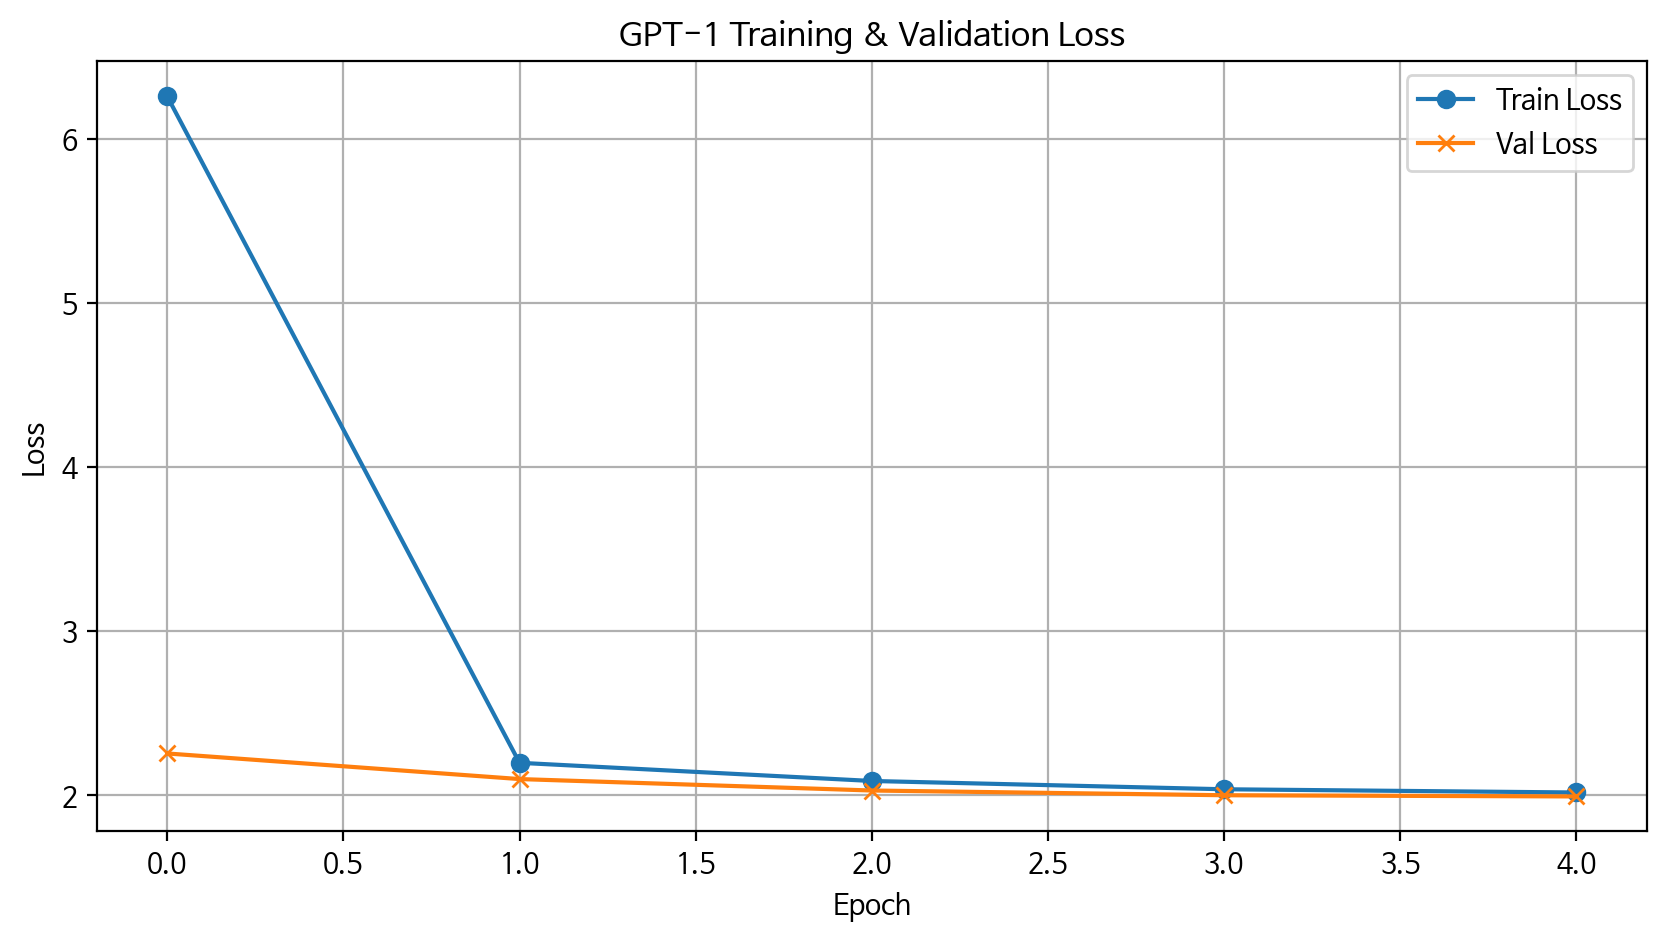

In [31]:
# 결과를 기록할 리스트
train_losses = []
val_losses = []
global_step = 0

print("🚀 본격적인 GPT-1 학습을 시작합니다.")

for epoch in range(1, EPOCHS + 1):
    # --- [TRAIN PHASE] ---
    model.train()
    total_train_loss = 0

    current_lr = scheduler.get_last_lr()[0]
    print(f"[Epoch {epoch}] lr(start) = {current_lr:.6e}")
    pbar = tqdm(train_loader, desc=f"Epoch {epoch} [Train]")

    for src, tgt in pbar:
        src = src.to(device)
        tgt = tgt.to(device)

        # GPT-1용 통합 마스크 생성
        mask = generate_gpt_mask(src)

        optimizer.zero_grad()

        # Forward pass
        logits, _ = model(src, mask)

        # Loss 계산
        loss = loss_function(tgt, logits)

        # Backward pass & Optimization
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0) # 그래디언트 클리핑
        optimizer.step()
        scheduler.step()

        total_train_loss += loss.item()
        pbar.set_postfix({'loss': f"{loss.item():.4f}", 'lr': f"{scheduler.get_last_lr()[0]:.2e}"})

    avg_train_loss = total_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # --- [VALIDATION PHASE] ---
    model.eval()
    total_val_loss = 0
    with torch.no_grad():
        for src, tgt in tqdm(val_loader, desc=f"Epoch {epoch} [Val]"):
            src, tgt = src.to(device), tgt.to(device)
            mask = generate_gpt_mask(src)
            logits, _ = model(src, mask)
            loss = loss_function(tgt, logits)
            total_val_loss += loss.item()

    avg_val_loss = total_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    # --- [BEST MODEL CHECK & SAVE] ---
    # 이번 에폭의 검증 손실이 이전까지의 기록보다 낮으면 저장합니다.
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss

        # 현재까지의 학습 기록 포함
        history = {'train_losses': train_losses, 'val_losses': val_losses}

        # 저장 함수 호출
        save_model(model, config, checkpoint_path, train_history=history)
        print(f"★ New Best Score! Val Loss: {avg_val_loss:.4f} - 모델이 업데이트되었습니다.")

    print(f"\n[Epoch {epoch}] Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
    print("-" * 50)

    # 샘플 테스트
    print("💬 Sample Q&A:")
    model.eval()
    for q in examples:
        ans, token_pieces, all_attns = generate_with_attention(q) # Adjusted unpacking to 3 values
        print("Q:", q)
        print("A:", ans)
    print("-" * 50)

# --- 학습 결과 시각화 ---
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss', marker='o')
plt.plot(val_losses, label='Val Loss', marker='x')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('GPT-1 Training & Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

### 10. BLEU 평가 + Attention 시각화

In [32]:
# =========================================
# 10. BLEU 평가 + Attention 시각화 예시
# =========================================
def eval_bleu_one(src_text, tgt_text, verbose=True):
    model.eval()# 전처리가 포함된 생성 함수 호출
    pred_tuple = generate_with_attention(src_text)
    pred = pred_tuple[0] # generated answer is the first element of the tuple

    # BLEU 계산을 위한 토큰화 (단어 단위 split)
    ref = [tgt_text.split()] # Reference는 리스트의 리스트 형태여야 함
    hyp = pred.split()       # Hypothesis

    smooth = SmoothingFunction().method1
    score = sentence_bleu(ref, hyp, smoothing_function=smooth)
    if verbose:
        print("Source :", src_text)
        print("Target :", tgt_text)
        print("Pred   :", pred)
        print(f"BLEU   : {score:.4f}")
    return score

# BLEU 예시 실행 (원본 데이터를 샘플로 사용)
print("\n=== BLEU Evaluation Examples ===")
for i in range(3):
    src = df["Q_clean"].iloc[i]
    tgt = df["A_clean"].iloc[i]
    eval_bleu_one(src, tgt)


=== BLEU Evaluation Examples ===
Source : 고양이 알러지는 없나?
Target : 있는 사람이 꽤 있더라고
Pred   : 어 ?  지 는 않 을 듯 키 키  ⁇  ! 
BLEU   : 0.0000
Source : 있는 사람이 꽤 있더라고
Target : 저 살짝 있어요 키키 심한 건 아니고
Pred   : 어떤 거 이 야 ?    은 ?  어떤 게임 이 야 ?   은  나 의  지 ?  어떤 거 같 어 키 키  이 ᆫ지  ⁇   어서  을 못 보 고  ⁇  하 어  ᆯ 거 이 ᆫ 거 이 라고 하 어  ᆯ 거 같 었 다  ⁇  키키  ⁇ 
BLEU   : 0.0036
Source : 저 살짝 있어요 키키 심한 건 아니고
Target : 아 진짜?
Pred   : ᆫ 거 이 ᆫ지 모르 겠 는데  ⁇   어서  ⁇  ...  ⁇ 
BLEU   : 0.0000



[질문]: 오늘 기분이 어때?
[답변]: 어서  ⁇  이 야 ?  ⁇   ⁇ 


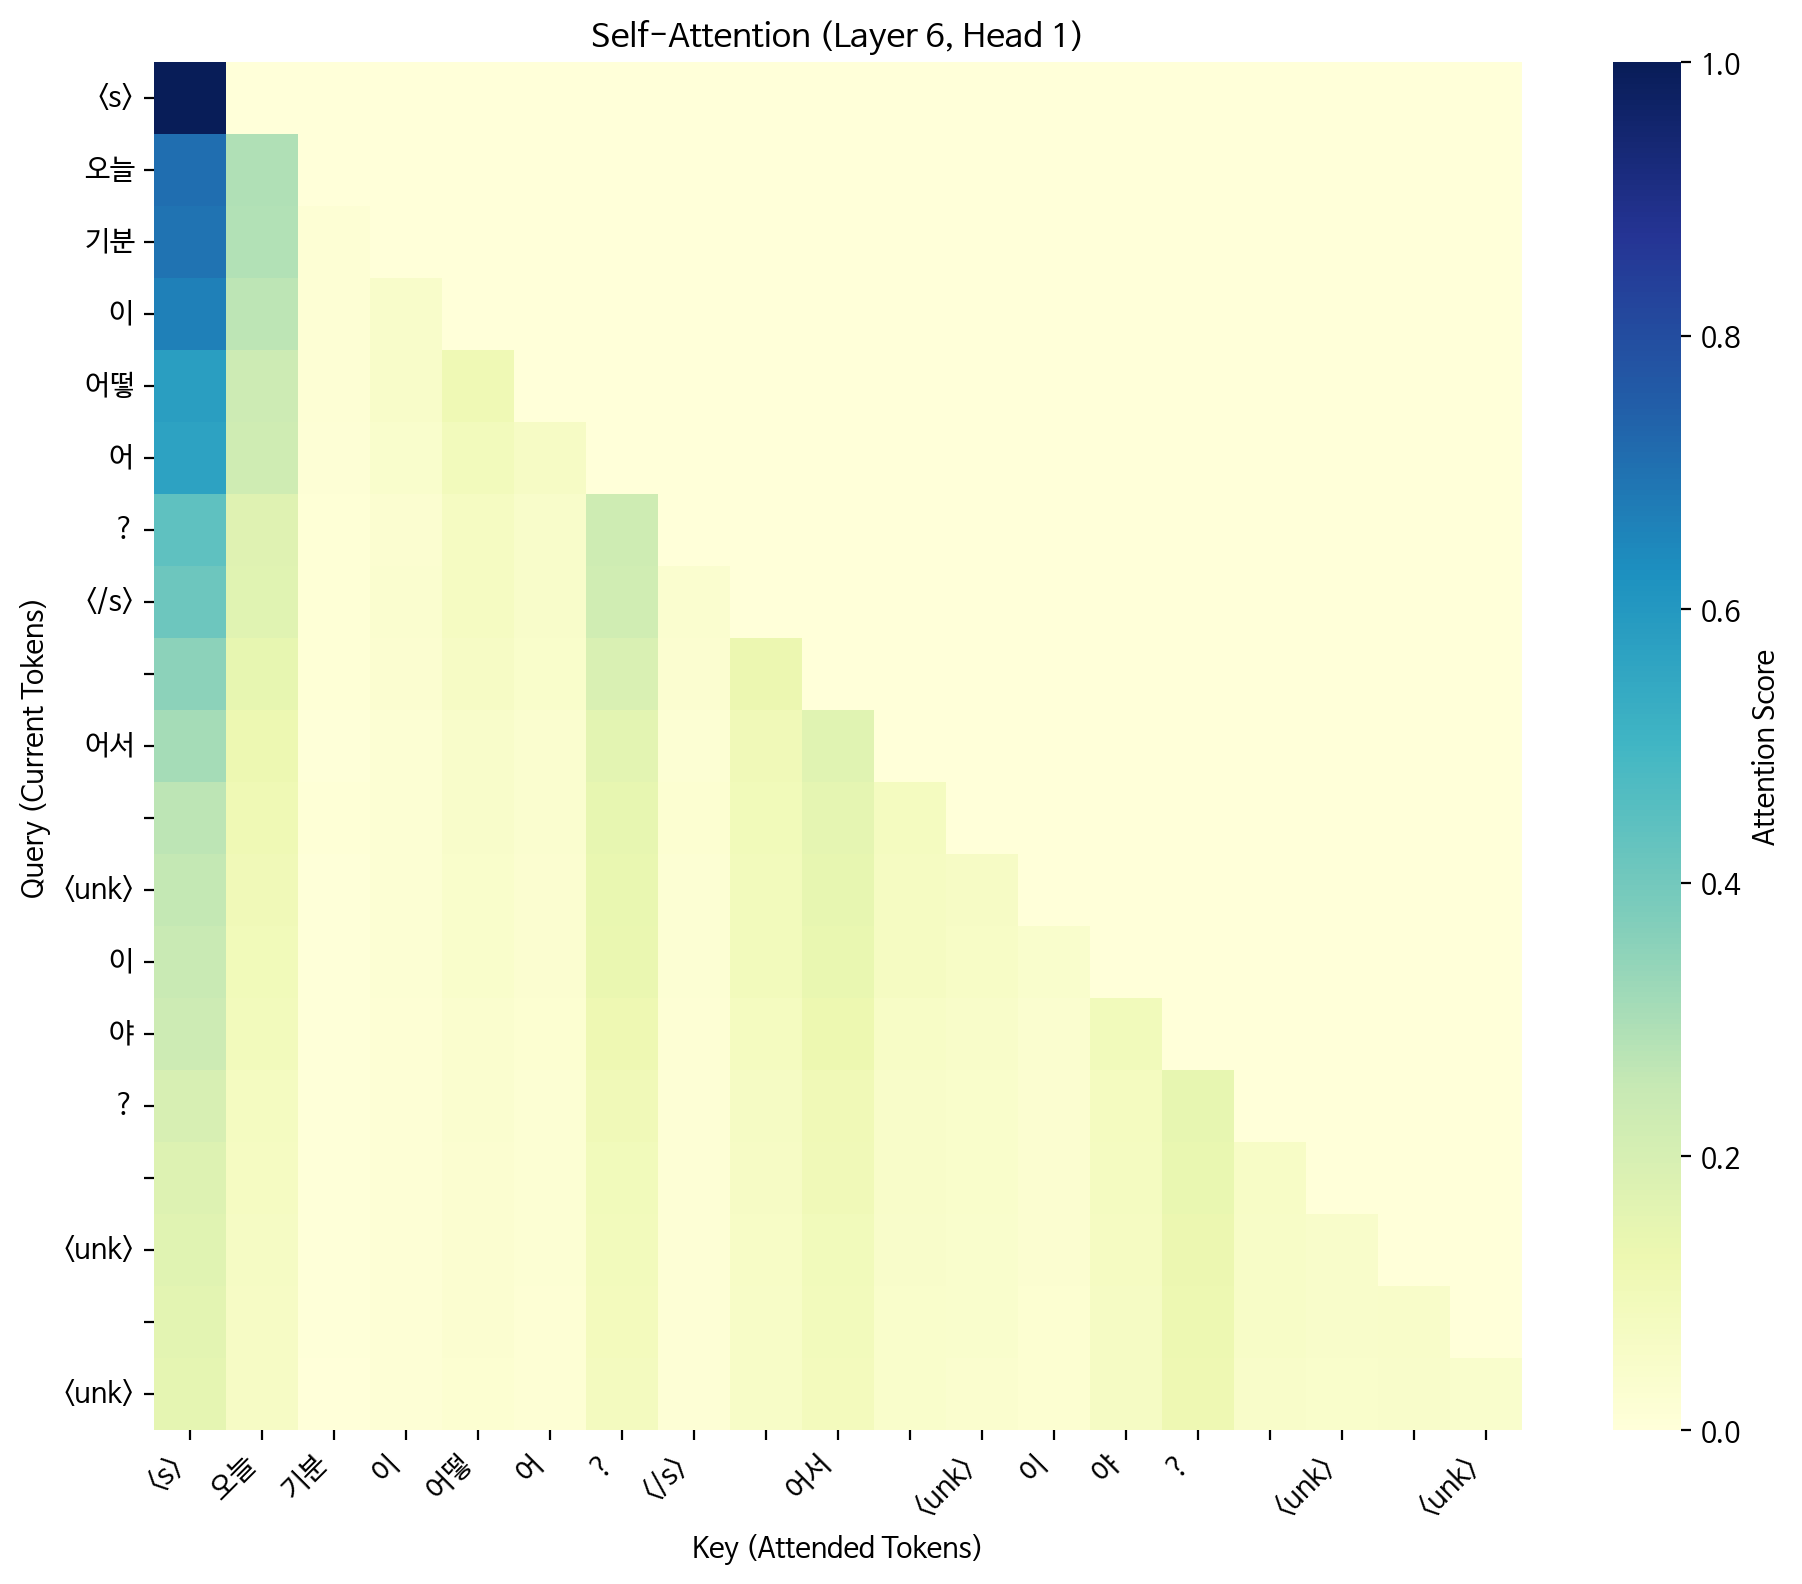

In [33]:

### Attention 시각화 1회 실행
q = "오늘 기분이 어때?"
pred_text, tokens, attns = generate_with_attention(q)

print(f"\n[질문]: {q}")
print(f"[답변]: {pred_text}")

# 앞서 정의한 visualize_gpt_attention 함수 호출
# layer=5 (마지막 층), head=0 시각화
visualize_gpt_attention(tokens, attns, layer=5, head=0)

# B. ChatBot 구현

### 런타임 재시작시 실행

먼저 A. 퀘스트 수행에서  
1. **0-2. 코랩 사용자를 위한 드라이브 연결** 전체코드와  
2. **9-2. 모델 저장** 중 model_dir 설정 코드 실행
3. 기타 데이터 전처리 , 토큰화 관련 클래스 부분 모두 실행

In [6]:
checkpoint_name = "best_gpt1_chatbot.pth"
checkpoint_path = os.path.join(model_dir,checkpoint_name)

In [39]:
if os.path.exists(checkpoint_path):
    print(f"✅ 파일을 찾았습니다: {checkpoint_path}")

    # 체크포인트 불러오기
    checkpoint = torch.load(checkpoint_path, map_location=device)
    config = checkpoint['config']

    # 모델 재구축 (클래스 정의가 먼저 실행되어 있어야 함!)
    model = GPT1(
        vocab_size=config['vocab_size'],
        d_model=config['d_model'],
        n_heads=config['n_heads'],
        d_ff=config['d_ff'],
        n_layers=config['n_layers'],
        max_len=config['max_len'],
        dropout=config['dropout']
    ).to(device)

    # 가중치 입히기
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    print("🚀 모델 복구가 성공적으로 완료되었습니다!")
else:
    print(f"❌ 파일을 찾을 수 없습니다: {checkpoint_path}")
    print("현재 폴더의 파일 목록을 확인해보세요:", os.listdir())

✅ 파일을 찾았습니다: /content/gdrive/MyDrive/#Study/Aiffel/Work/GPT/model/best_gpt1_chatbot.pth
🚀 모델 복구가 성공적으로 완료되었습니다!


### 챗봇

In [34]:
import sys

# 만약 로컬 환경에서 실제 ESC 키를 감지하고 싶다면 아래 라이브러리가 필요합니다.
# !pip install keyboard
try:
    # import keyboard # Removed keyboard import
    keyboard = None # Set keyboard to None to disable its usage
except ImportError:
    keyboard = None

In [35]:
def start_chatting(model, tokenizer, device, max_len=40):
    """
    학습된 모델과 대화를 나누는 루프를 실행합니다.
    """
    model.eval()  # 평가 모드 전환

    print("="*50)
    print("   나만의 GPT-1 챗봇과 대화를 시작합니다!")
    print("   (종료하려면 'esc'를 입력하거나 ESC 키를 누르세요)")
    print("="*50)

    while True:
        # 1. 사용자 입력 받기
        user_input = input("\n나: ").strip()

        # 2. 종료 조건 체크 (입력값이 'esc'이거나 키보드 이벤트 발생 시)
        if user_input.lower() == 'esc':
            print("\n챗봇: 다음에 또 봐요! 안녕~")
            break

        # 키보드 라이브러리가 설치된 경우 ESC 키 눌림 감지 (이 부분은 Colab 환경에서 문제를 일으켜 주석 처리)
        # if keyboard and keyboard.is_pressed('esc'):
        #     print("\n챗봇: ESC 신호를 확인했어요. 종료합니다!")
        #     break

        if not user_input:
            continue

        # 3. 답변 생성
        # 반환값: decoded, src_pieces, tgt_pieces, enc_attns, dec_attns, decenc_attns
        try:
            response, _, _ = generate_with_attention(
                user_input,
                max_len=max_len
            )

            print(f"챗봇: {response}")

        except Exception as e:
            print(f"에러가 발생했어요: {e}")

In [36]:
# 챗봇 실행
# (이미 model, tokenizer, device가 메모리에 로드되어 있어야 합니다)
start_chatting(model, tokenizer, device)

   나만의 GPT-1 챗봇과 대화를 시작합니다!
   (종료하려면 'esc'를 입력하거나 ESC 키를 누르세요)

나: 안녕, 오늘 뭐했어?
챗봇: ?  지나가 었 어요 ?  이 ᆫ가 ?  ⁇   ⁇  ?  ⁇ 

나: 너 데이터의 정규화가 너무 많이 필요하다
챗봇: 도 그렇 고  ⁇   지 않 을까 ?  어  도 안 그렇 고  도  ⁇   

나: 무슨 물음표를 이리 많이 뱉어내
챗봇: 버리 어 버리 었 어  ⁇    ᆯ 때  이 었 어  ⁇   ⁇ 

나: 암튼... 데이터가 많아도 챗봇이 똑똑해지는 건 아니구나
챗봇:  ⁇  이  ⁇ 

나: 그만 안녕
챗봇: 

나: esc

챗봇: 다음에 또 봐요! 안녕~
